In [1]:
import sys
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import os 
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt 


from propa.rtf.rtf_localisation.zhang_et_al_testcase.deprecated.zhang_params import ROOT_DATA
from propa.rtf.rtf_estimation.rtf_estimation_utils import rtf_covariance_subtraction, rtf_covariance_whitening
from propa.rtf.rtf_utils import D_hermitian_angle_fast
from misc import cast_matrix_to_target_shape


# from matplotlib import rcParams
# rcParams["backend"] = "ipympl"

In [2]:
# Load tf
fpath_tf = os.path.join(ROOT_DATA, "tf_zhang_grid_dx20m_dy20m.nc")
ds_tf = xr.open_dataset(fpath_tf)
# Build complex tf
tf = ds_tf.tf_real + 1j * ds_tf.tf_imag

In [3]:
tf

<xarray.DataArray (idx_rcv: 6, f: 10001, y: 10, x: 11)> Size: 106MB
array([[[[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         ...,
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],

        [[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         ...,
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],

        [[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         ...,
...
         ...,
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],

        [[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         ...,
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],

        [[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         ...,
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]]]])
Coordinates:
  * f        (f) float64 80kB 0.0 0.1 0.2 0.3 0.4 ... 999.7 999.8 999.9 1e+03
  * y        (y) float64 80B 6.7e+03 6.72e+03 6.74e+03 ... 6.86e+03 6.88e+03
  * x        (x) float64 88B 3.8e+03 3.82e+03 3.84e+03 ... 3.98e+03 4e+03
  * idx_rcv  (idx_rcv) int32 24B 0 1 2 3 4 5

In [4]:
# Load propagated signal
fpath_sig = os.path.join(ROOT_DATA, "zhang_library_dx20m_dy20m.nc")
ds_sig = xr.open_dataset(fpath_sig)


In [5]:
ds_sig

<xarray.Dataset> Size: 64MB
Dimensions:  (idx_rcv: 6, t: 12000, y: 10, x: 11)
Coordinates:
  * idx_rcv  (idx_rcv) int32 24B 0 1 2 3 4 5
  * y        (y) float64 80B 6.7e+03 6.72e+03 6.74e+03 ... 6.86e+03 6.88e+03
  * x        (x) float64 88B 3.8e+03 3.82e+03 3.84e+03 ... 3.98e+03 4e+03
  * t        (t) float64 96kB 0.0 0.0008333 0.001667 ... 9.998 9.998 9.999
Data variables:
    s_l      (idx_rcv, t, y, x) float64 63MB ...
    s_e      (idx_rcv, t) float64 576kB ...
Attributes:
    df:        0.1
    dx:        20
    dy:        20
    testcase:  zhang_et_al_2023

In [6]:
# Define a position to study 
xs, ys = 3900, 6800
# Select sig and tf at pos 
tf_s = tf.sel(x=xs, y=ys, method="nearest")
sig = ds_sig.s_l.sel(x=xs, y=ys, method="nearest")

In [7]:
tf_s

<xarray.DataArray (idx_rcv: 6, f: 10001)> Size: 960kB
array([[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]])
Coordinates:
  * f        (f) float64 80kB 0.0 0.1 0.2 0.3 0.4 ... 999.7 999.8 999.9 1e+03
    y        float64 8B 6.8e+03
    x        float64 8B 3.9e+03
  * idx_rcv  (idx_rcv) int32 24B 0 1 2 3 4 5

In [8]:
sig

<xarray.DataArray 's_l' (idx_rcv: 6, t: 12000)> Size: 576kB
[72000 values with dtype=float64]
Coordinates:
  * idx_rcv  (idx_rcv) int32 24B 0 1 2 3 4 5
    y        float64 8B 6.8e+03
    x        float64 8B 3.9e+03
  * t        (t) float64 96kB 0.0 0.0008333 0.001667 ... 9.998 9.998 9.999

In [1]:
# Define reference receiver to use
idx_rcv_ref = 0
# Build true rtf
rtf_s = tf_s / tf_s.sel(idx_rcv=idx_rcv_ref)
# Select band of interest
fmin = 100
fmax = 500
rtf_s = rtf_s.sel(f=slice(fmin, fmax))

NameError: name 'tf_s' is not defined

In [10]:
rtf_s

<xarray.DataArray (idx_rcv: 6, f: 4001)> Size: 384kB
array([[ 1.        -0.00000000e+00j,  1.        +0.00000000e+00j,
         1.        +3.63225290e-17j, ...,  1.        +6.32078460e-17j,
         1.        +0.00000000e+00j,  1.        -0.00000000e+00j],
       [ 0.61909739+8.82130075e-01j,  0.5328429 +9.75761274e-01j,
         0.50735431+1.18557253e+00j, ...,  0.26213329-4.44614156e-01j,
         0.2847593 -4.44101847e-01j,  0.30839982-4.42348576e-01j],
       [-0.64463565+1.16688996e+00j, -0.801184  +8.36652842e-01j,
        -1.45785034+8.33021672e-01j, ...,  0.40791302+1.97023352e-01j,
         0.36911711+2.36278077e-01j,  0.32869293+2.69049424e-01j],
       [-1.1079571 +5.73195891e-01j, -1.23964911+3.28694664e-01j,
        -1.85843831-1.83468693e-01j, ..., -0.3724504 +4.98107348e-01j,
        -0.48893722+4.37881193e-01j, -0.59664321+3.47905202e-01j],
       [ 1.20415566+1.50289886e-01j,  1.11498631+3.71908195e-01j,
         1.3002791 +9.51240331e-01j, ..., -0.51454278+1.01169324e-01j,
        -0.50655462+3.31588265e-02j, -0.49051252-2.95241153e-02j],
       [ 0.84455314-5.59272547e-01j,  0.96725575-4.48752111e-01j,
         1.17462471-5.86717719e-01j, ..., -0.49385152-1.37079639e-01j,
        -0.49929545-1.57742446e-01j, -0.50365022-1.79644440e-01j]])
Coordinates:
  * f        (f) float64 32kB 100.0 100.1 100.2 100.3 ... 499.8 499.9 500.0
    y        float64 8B 6.8e+03
    x        float64 8B 3.9e+03
  * idx_rcv  (idx_rcv) int32 24B 0 1 2 3 4 5

In [11]:
# Estimate rtf from signal
snr = 15
# Build noise
sigma_rcv_ref = np.std(sig.sel(idx_rcv=idx_rcv_ref))
# Normalize to account for the reference signal power to reach required snr at receiver n°0
sigma = sigma_rcv_ref * np.sqrt(10 ** (-snr / 10))
# Noise
noise = np.random.normal(loc=0, scale=sigma, size=sig.shape)    # Noise to estimate noise covariance matrix 
noise_mix = np.random.normal(loc=0, scale=sigma, size=sig.shape)    # Noise to add to signal 

In [12]:
noise.shape

(6, 12000)

In [13]:
# Check SNR
snr_hat = 10 * np.log10(
    np.var(sig.sel(idx_rcv=idx_rcv_ref).values) / np.var(noise[idx_rcv_ref, :])
)
print(f"SNR at receiver n°0 : {np.round(snr_hat, 2)} dB (required {snr}dB)")

SNR at receiver n°0 : 14.97 dB (required 15dB)


In [14]:
nperseg = 2**11
noverlap = nperseg // 2
print(nperseg, noverlap)

2048 1024


In [15]:
t = sig.t.values
noisy_sig = sig + noise_mix
f_cs, rtf_hat_cs, _, _, _ = rtf_covariance_subtraction(
    t=t,
    noisy_signal=noisy_sig.T,
    noise_only=noise.T,
    nperseg=nperseg,
    noverlap=noverlap,
)
f_cw, rtf_hat_cw, _, _, _ = rtf_covariance_whitening(
    t=t, noisy_signal=noisy_sig.T, noise_only=noise.T, nperseg=nperseg, noverlap=noverlap
)

In [16]:
rtf_hat_cs.shape

(1025, 6)

Text(0, 0.5, '$|\\Pi(f)|$')

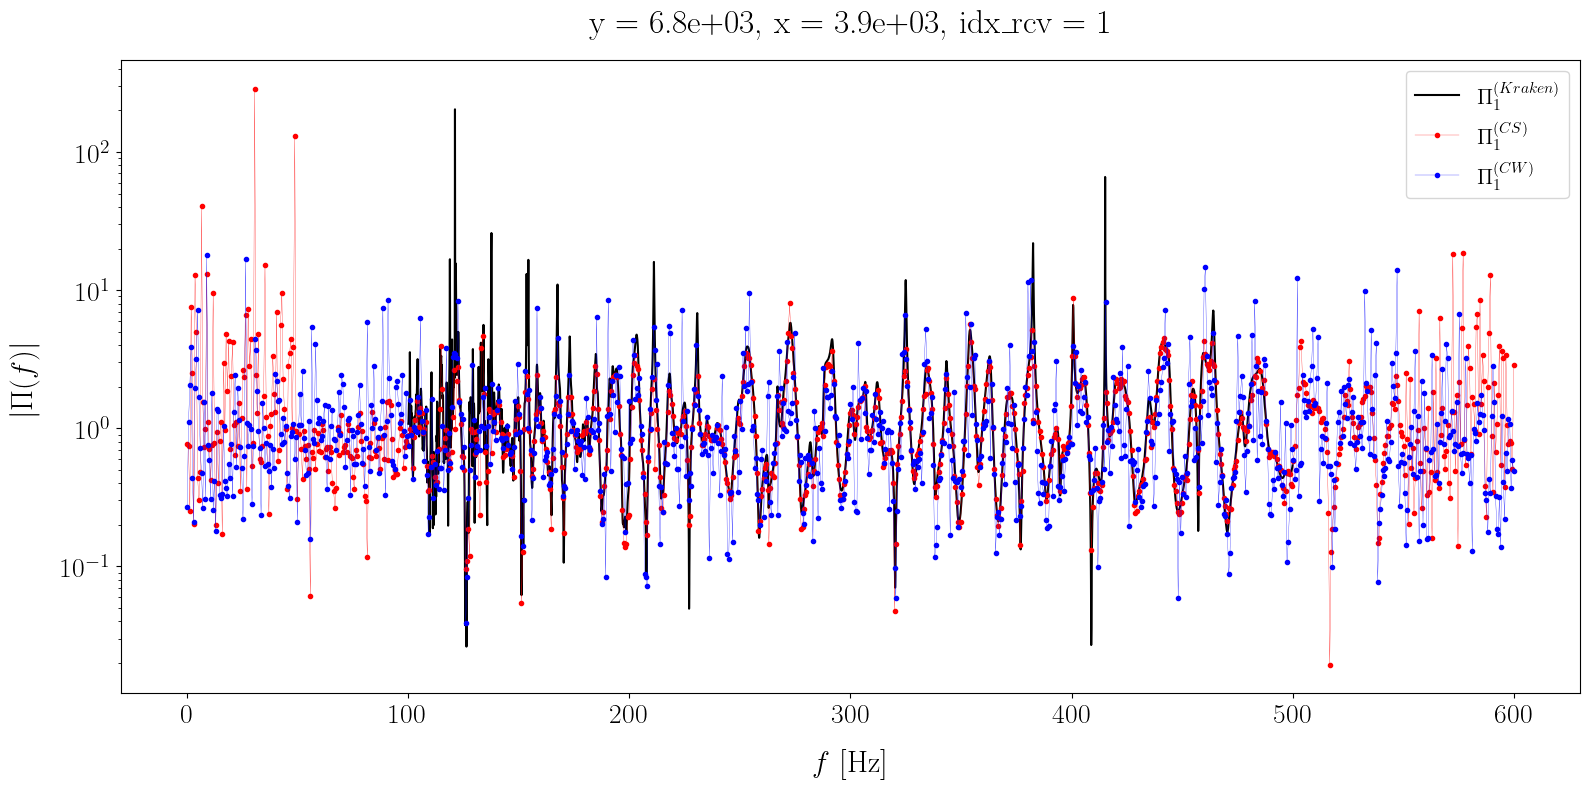

In [17]:
ircv = 1
rtf_s_abs = np.abs(rtf_s)
# Compare
plt.figure()
rtf_s_abs.sel(idx_rcv=ircv).plot(
    x="f",
    label=r"$\Pi_{" + str(ircv) + r"}^{(Kraken)}$",
    linestyle="-",
    color="k",
    linewidth=1.5,
)
plt.plot(
    f_cs,
    np.abs(rtf_hat_cs[:,ircv]),
    linestyle="-",
    label=r"$\Pi_{" + str(ircv) + r"}^{(CS)}$",
    color="r",
    marker="o",
    linewidth=0.2,
    markersize=3,
)
plt.plot(
    f_cw,
    np.abs(rtf_hat_cw[:, ircv]),
    linestyle="-",
    label=r"$\Pi_{" + str(ircv) + r"}^{(CW)}$",
    color="b",
    marker="o",
    linewidth=0.2,
    markersize=3,
)
plt.legend()
plt.yscale("log")
plt.xlabel(r"$f$" + " [Hz]")
plt.ylabel(r"$|\Pi(f)|$")

# Introduce functions

In [18]:
def generate_noise(z, snr, idx_rcv_ref=0):
    # Build noise
    sigma_rcv_ref = np.std(z.sel(idx_rcv=idx_rcv_ref))
    # Normalize to account for the reference signal power to reach required snr at receiver n°0
    sigma = sigma_rcv_ref * np.sqrt(10 ** (-snr / 10))
    # Noise
    noise = np.random.normal(loc=0, scale=sigma, size=sig.shape)    # Noise to estimate noise covariance matrix 
    noise_mix = np.random.normal(loc=0, scale=sigma, size=sig.shape)    # Noise to add to signal 

    return noise, noise_mix

In [47]:
def get_rtf_estimate_single_snr(z, snr, estimators, idx_rcv_ref=0):
    # Generate noise
    v, v_mix = generate_noise(z, snr, idx_rcv_ref=idx_rcv_ref)

    # Mix signal 
    x = z + v_mix

    # Init res 
    res = {}
    # Estimate rtf 
    for e in estimators:
        if e == "cs":
            f, rtf, _, _, _ = rtf_covariance_subtraction(
                t=t,
                noisy_signal=x.T,
                noise_only=v.T,
                nperseg=nperseg,
                noverlap=noverlap,
            )
        elif e == "cw":
            f, rtf, _, _, _ = rtf_covariance_whitening(
                t=t, noisy_signal=x.T, noise_only=v.T, nperseg=nperseg, noverlap=noverlap
            )
        res[e] = {"f":f, "rtf":rtf.T}
    
    return res

In [48]:
def plot_rtfs(rtf_ref, rtfs_hat, ircv=1):
    plt.figure()
    np.abs(rtf_ref).sel(idx_rcv=ircv).plot(
        x="f",
        label=r"$\Pi_{" + str(ircv) + r"}^{(Kraken)}$",
        linestyle="-",
        color="k",
        linewidth=1.5,
    )
    for e in rtfs_hat.keys():
        rtf = rtfs_hat[e]
        plt.plot(
            rtf["f"],
            np.abs(rtf["rtf"][ircv, :]),
            linestyle="-",
            label=r"$\Pi_{" + str(ircv) + r"}^{(" + e.upper() + r")}$",
            # color="r",
            marker="o",
            linewidth=0.2,
            markersize=3,
        )
    plt.legend()
    plt.yscale("log")
    plt.xlabel(r"$f$" + " [Hz]")
    plt.ylabel(r"$|\Pi(f)|$")
    plt.xlim([100, 500])

In [49]:
sig

<xarray.DataArray 's_l' (idx_rcv: 6, t: 12000)> Size: 576kB
array([[ 1.228620e-05, -2.110482e-05, -4.640396e-05, ..., -6.119313e-06,
         2.321979e-05, -1.504929e-05],
       [-7.851881e-06, -1.516811e-06, -1.525817e-05, ..., -1.721493e-05,
        -3.353621e-05,  1.422074e-05],
       [ 5.754998e-07, -4.371804e-06,  4.433726e-05, ..., -5.400222e-06,
         1.011652e-05,  5.998986e-06],
       [-2.459261e-05, -1.916903e-05,  5.831565e-07, ..., -2.832797e-06,
        -4.383197e-06,  1.861141e-05],
       [-1.277492e-05, -1.166269e-06,  1.132510e-05, ...,  9.156007e-06,
        -2.887033e-05, -1.406300e-05],
       [-1.003923e-05, -3.996360e-05,  1.212535e-05, ...,  1.046996e-05,
        -8.175081e-06,  2.361748e-05]])
Coordinates:
  * idx_rcv  (idx_rcv) int32 24B 0 1 2 3 4 5
    y        float64 8B 6.8e+03
    x        float64 8B 3.9e+03
  * t        (t) float64 96kB 0.0 0.0008333 0.001667 ... 9.998 9.998 9.999

In [50]:
rtfs_hat = get_rtf_estimate_single_snr(
    z=sig, snr=10, estimators=["cs", "cw"], idx_rcv_ref=0
)

In [51]:
rtfs_hat["cs"]

{'f': array([0.00000000e+00, 5.85937500e-01, 1.17187500e+00, ...,
        5.98828125e+02, 5.99414062e+02, 6.00000000e+02]),
 'rtf': array([[ 1.        +0.j        ,  1.        +0.j        ,
          1.        +0.j        , ...,  1.        +0.j        ,
          1.        -0.j        ,  1.        +0.j        ],
        [-0.49015667+0.j        , -0.2363397 -0.02378371j,
         -0.10857997+0.59682284j, ...,  1.31698043-0.88377061j,
         -2.14343862+1.54104925j,  0.18642237+0.j        ],
        [-0.09341436+0.j        ,  0.50064264-0.54636224j,
          0.18895544-0.35141824j, ...,  1.76765184-0.02676265j,
          1.1610265 +7.55354187j, -2.53892303+0.j        ],
        [-0.37867717+0.j        , -0.4380341 +0.22761892j,
         -0.5093765 +1.09104232j, ..., -0.85019002-0.23395825j,
          2.48224493+3.70845385j, -0.54960418+0.j        ],
        [ 1.07722459+0.j        ,  1.31530734+0.03412914j,
          1.89774901+0.30132355j, ..., -5.23437238-1.68172149j,
         -1.94

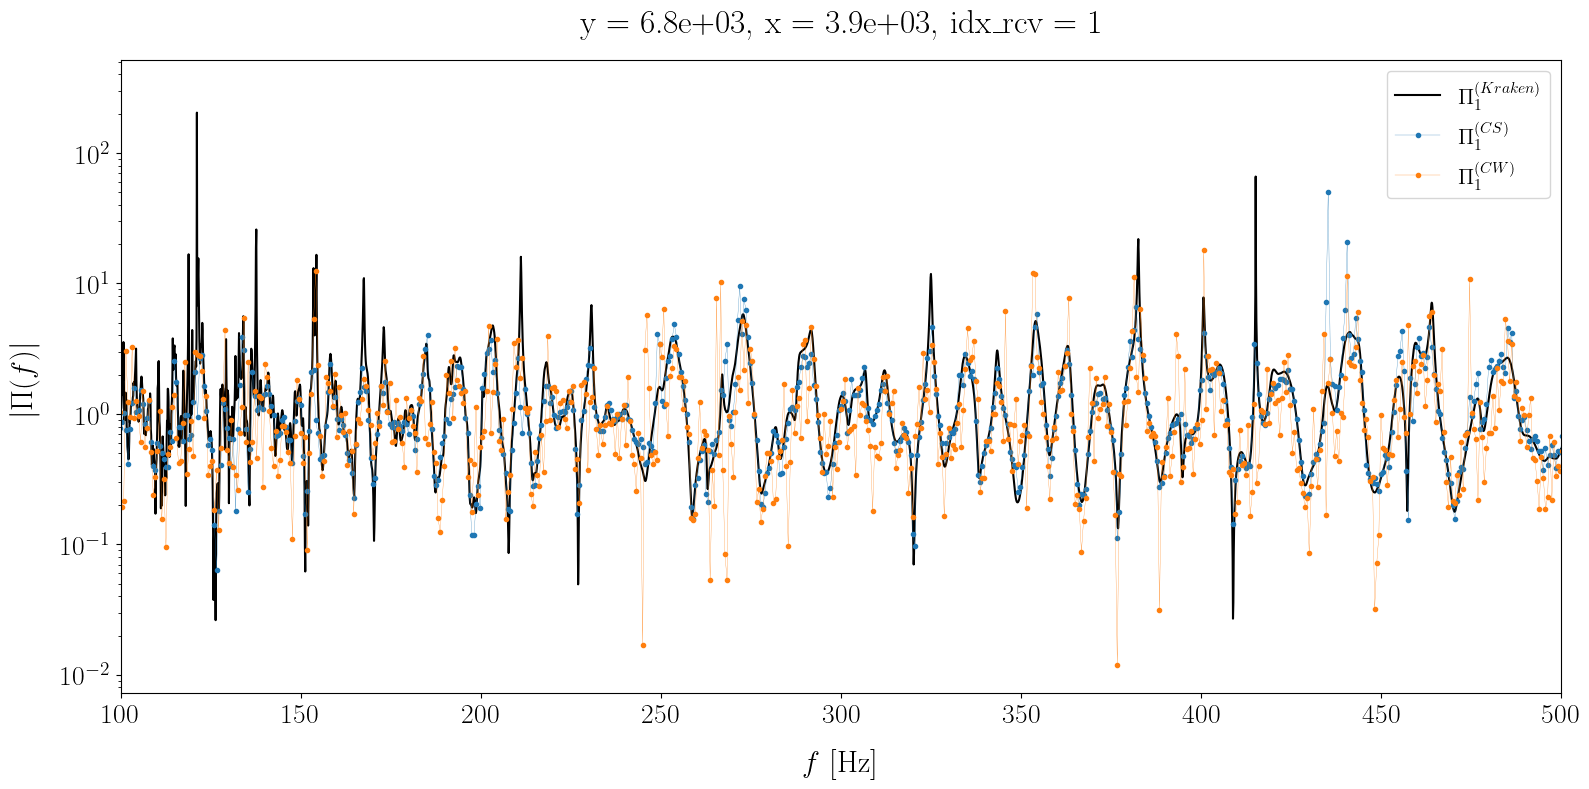

In [52]:
plot_rtfs(rtf_ref=rtf_s, rtfs_hat=rtfs_hat, ircv=1)

In [53]:
def monte_carlo_single_snr(z, snr, estimators, n_mc=1000, idx_rcv_ref=0):
    rtfs_hat = get_rtf_estimate_single_snr(
        z=z, snr=snr, estimators=estimators, idx_rcv_ref=idx_rcv_ref
    )
    res_mc = {e:{"f": rtfs_hat[e]["f"], "rtf":[rtfs_hat[e]["rtf"]]} for e in estimators}

    # For easy reshape later 
    n_mc_root = np.ceil(np.sqrt(n_mc))
    n_mc = int(n_mc_root ** 2) 
    # print(n_mc)
    res_mc["n_mc"] = n_mc
    
    for i in range(1, n_mc):
        rtfs_hat = get_rtf_estimate_single_snr(
            z=z, snr=snr, estimators=estimators, idx_rcv_ref=idx_rcv_ref
        )
        for e in estimators:
            res_mc[e]["rtf"].append(rtfs_hat[e]["rtf"])
    
    return res_mc

In [54]:
res_mc = monte_carlo_single_snr(z=sig, snr=10, estimators=["cs", "cw"], n_mc=10, idx_rcv_ref=0)

In [55]:
def analyse_perf_single_snr(rtf_ref, res_mc):
    estimators = [k for k in res_mc.keys() if k != "n_mc"]
    perf = {e:{"mean":None, "median":None, "std":None} for e in estimators}

    dist_func = D_hermitian_angle_fast
    dist_kwargs = {
        "ax_rcv": 0,
        "unit": "deg",
        "apply_mean": True,
        "ax_f": 1,
    }
    a = b = int(np.sqrt(res_mc["n_mc"]))
    # print(rtf_ref.shape)
    rtf_ref_b = cast_matrix_to_target_shape(
        rtf_ref, rtf_ref.shape + (a, b)
    )  # Mimic y, x dims to avoid looping over mc iterations

    for e in estimators:

        rtf_hat = np.array(res_mc[e]["rtf"])
        # Move mc axis in last position
        rtf_hat = np.moveaxis(rtf_hat, 0, -1)
        rtf_hat_b = rtf_hat.reshape(
            rtf_ref_b.shape
        )  # Mimic y, x dims to avoid looping over mc iterations

        # Compute hermitian angle
        dist_grid = dist_func(rtf_ref_b, rtf_hat_b, **dist_kwargs)

        perf[e]["mean"] = np.mean(dist_grid)
        perf[e]["median"] = np.median(dist_grid)
        perf[e]["std"] = np.std(dist_grid)

    return perf

In [56]:
f_hat = res_mc["cs"]["f"]
rtf_s_interp  = rtf_s.sel(f=f_hat, method="nearest")
analyse_perf_single_snr(rtf_ref=rtf_s_interp, res_mc=res_mc)

{'cs': {'mean': 30.228264752380063,
  'median': 30.238007848653012,
  'std': 0.17785776065517303},
 'cw': {'mean': 37.817100153903105,
  'median': 37.79950731235854,
  'std': 0.2537793368322685}}

In [57]:
def process_snrs(snrs, z, rtf_ref_interp, estimators, n_mc, idx_rcv_ref=0):
    metrics = ["mean", "median", "std"]
    res = {e:{metric:[] for metric in metrics} for e in estimators}

    for snr in snrs: 
        res_snr = monte_carlo_single_snr(
            z=z, snr=snr, estimators=estimators, n_mc=n_mc, idx_rcv_ref=idx_rcv_ref
        )
        perf_snr = analyse_perf_single_snr(rtf_ref=rtf_ref_interp, res_mc=res_snr)

        for e in estimators:
            for metric in metrics:
                res[e][metric].append(perf_snr[e][metric])

    res["snr"] = snrs

    return res

In [58]:
estimators = ["cs", "cw"]
snrs = [0, 10, 20]
n_mc = 10

perf = process_snrs(
    snrs=snrs,
    z=sig,
    rtf_ref_interp=rtf_s_interp,
    estimators=estimators,
    n_mc=n_mc,
    idx_rcv_ref=0,
)

In [59]:
perf

{'cs': {'mean': [43.74371984238505, 30.14956519175562, 28.52320808710251],
  'median': [43.70139816051868, 30.142407622343903, 28.547968058342533],
  'std': [0.3676776216966957, 0.21435622566755883, 0.16218668115744903]},
 'cw': {'mean': [44.60285401966625, 37.75769165651664, 36.95608688187145],
  'median': [44.57396993568288, 37.79912356651006, 36.98872796437658],
  'std': [0.35001046079380893, 0.35168659491650145, 0.28411743812328255]},
 'snr': [0, 10, 20]}

In [60]:
def plot_perf(perf, use_median=True):
    estimators = [k for k in perf.keys() if k != "snr"]
    snr = perf["snr"]

    if use_median:
        m = "median"
    else:
        m = "mean"

    plt.figure()
    for e in estimators:
        plt.errorbar(snr, perf[e][m], yerr=perf[e]["std"], label=e.upper())

    plt.xlabel("SNR [dB]")
    plt.ylabel(r"$\theta$" + " [°]")
    plt.legend()
    

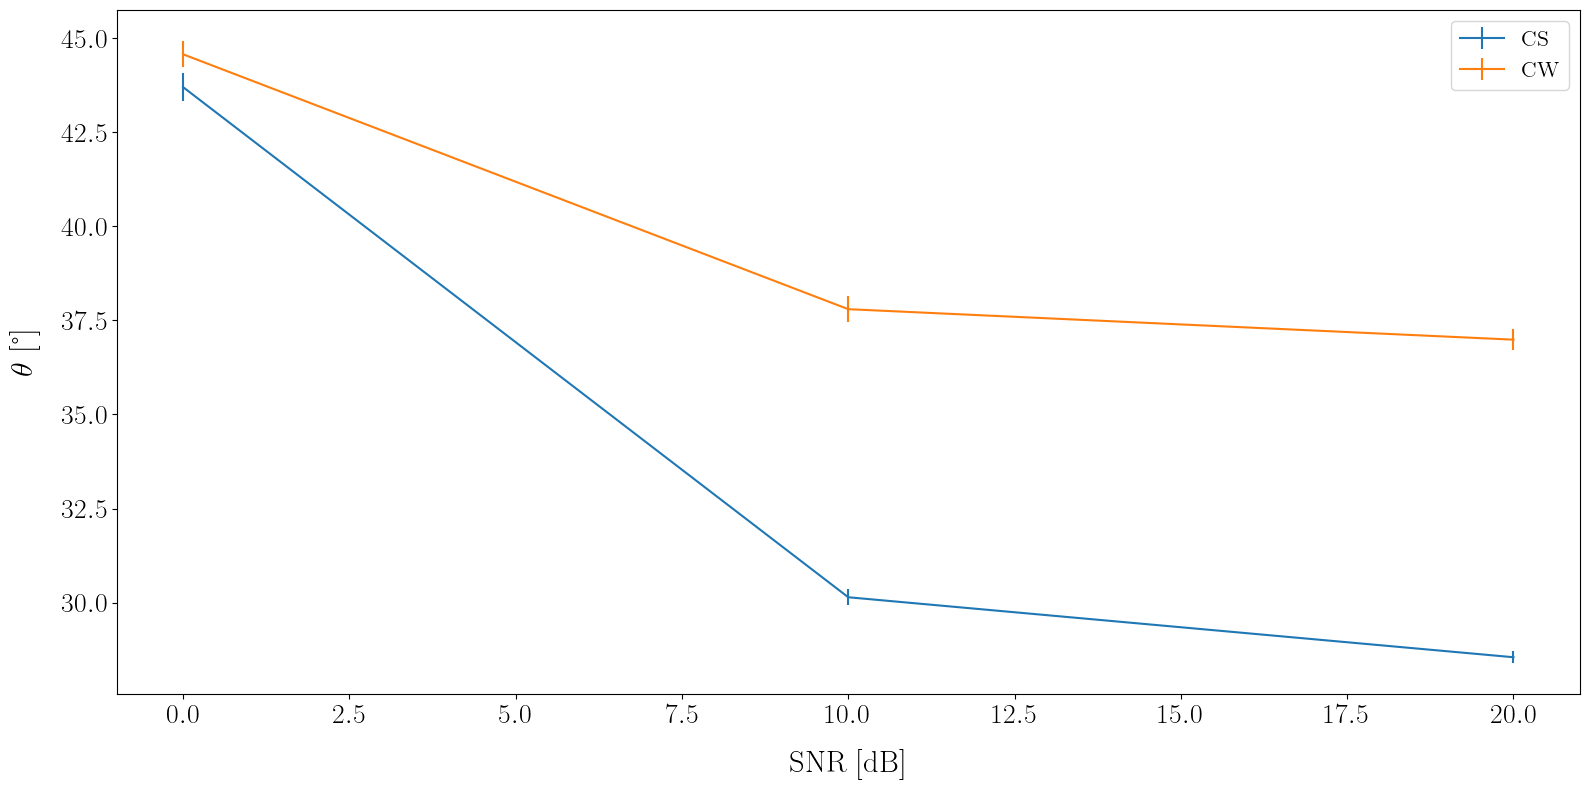

In [61]:
plot_perf(perf)

# Put it al together 

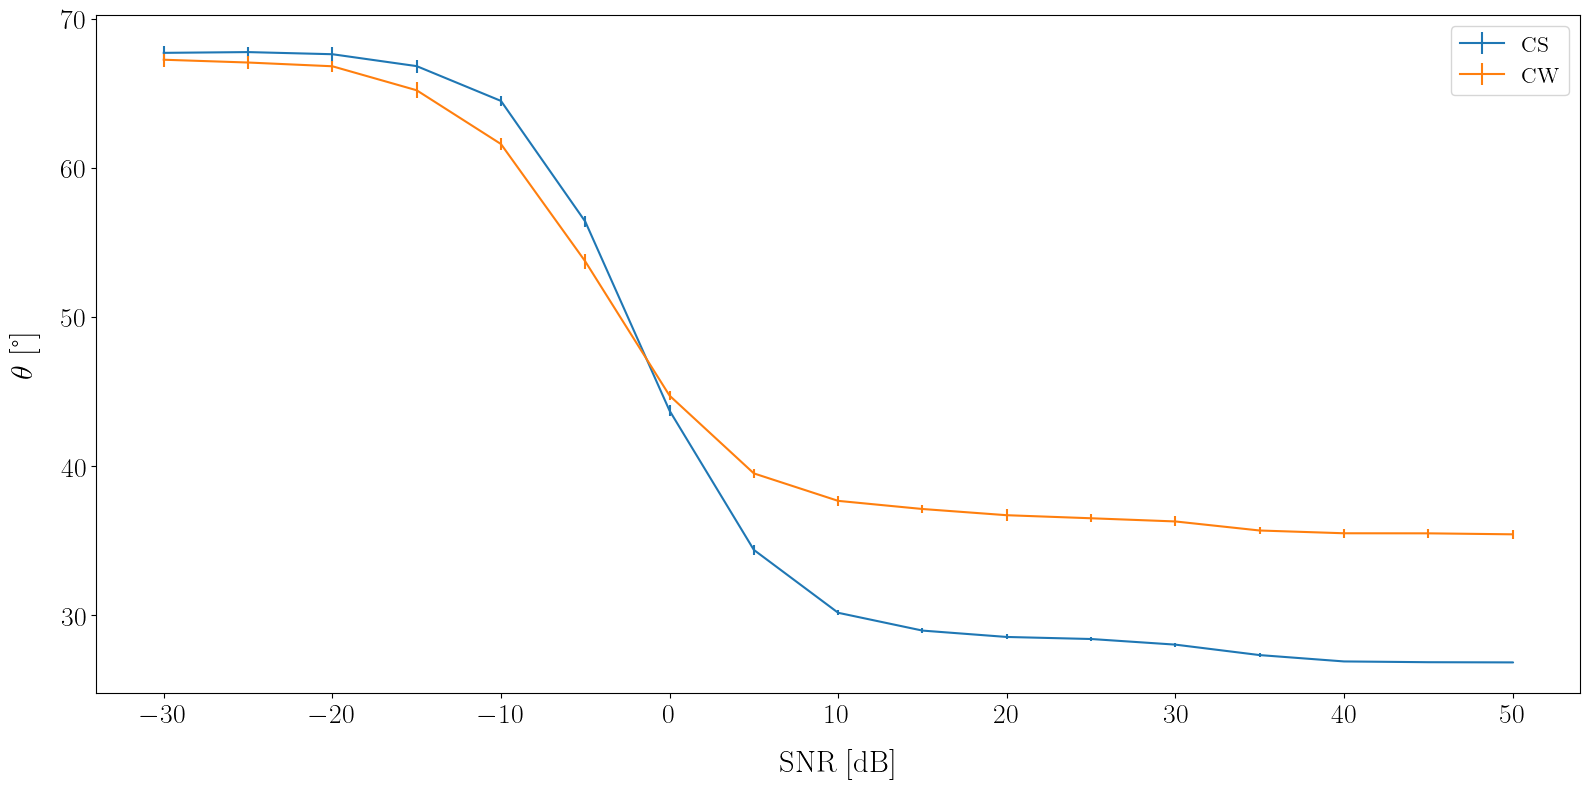

In [63]:
estimators = ["cs", "cw"]
n_mc = 10

snr_min = -30
snr_max = 50
snr_step = 5
n_snr = int((snr_max - snr_min) / snr_step + 1)
snrs = np.linspace(snr_min, snr_max, n_snr)

perf = process_snrs(
    snrs=snrs,
    z=sig,
    rtf_ref_interp=rtf_s_interp,
    estimators=estimators,
    n_mc=n_mc,
    idx_rcv_ref=0,
)
plot_perf(perf)

# Essayons d'utiliser les estimateurs du package SVD-direct